<div style="text-align:center; font-family: 'Georgia', serif; padding: 40px 60px; border-bottom: 2px solid #2c3e50;">

# EEG Band Power Statistical Analysis: Expert vs Novice Meditators
### Dataset: OpenNeuro ds001787 — Meditation EEG

**Giulia Finotto¹**

*¹ Department of Brain and Behavioral Sciences, University of Pavia, Pavia, Italy*

**Correspondence:** giulia.finotto01@universitadipavia.it

</div>

---
## Notebook Structure

| Section | Content |
|---------|--------|
| 0 | Library imports |
| 1 | Data loading: `results_all_subjects.csv` + `participants.tsv` |
| 2 | Merge, group assignment, and data cleaning |
| 3 | Descriptive statistics by group |
| 4 | Welch's t-test for each frequency band |
| 5 | Benjamini–Hochberg FDR correction |
| 6 | Effect size: Cohen's d |
| 7 | Pearson correlation: theta ~ alpha |
| 8 | Visualisations |
| 9 | Final summary table and CSV export |

> **Prerequisites:**
> - `results_all_subjects.csv` — produced by the main EEG preprocessing pipeline
> - `participants.tsv` — BIDS sidecar at the dataset root (`ds001787/participants.tsv`)
>
> Both files must be accessible via the paths defined in Section 1.
>
> **No external statistics packages required** (no statsmodels, no pingouin).
> All procedures are implemented from scratch using only `numpy` and `scipy.stats`.

---
## 0. Library Imports

In [1]:
import pandas as pd
import numpy as np
from scipy import stats          # Welch t-test, Pearson correlation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")
import scipy; print(f"scipy   {scipy.__version__}")

pandas  2.3.3
numpy   2.2.6
scipy   1.15.2


---
## 1. Data Loading

### Two input files

**`results_all_subjects.csv`** contains one row per subject with the band power values (in dB) computed by the main EEG preprocessing pipeline:

```
subject | n_channels | ... | delta_dB | theta_dB | alpha_dB | beta_dB | gamma_dB
001     | 64         | ... | -115.08  | -120.07  | -117.13  | -126.58 | -131.27
```

**`participants.tsv`** is the BIDS-mandated metadata file at the dataset root. It contains one row per subject with demographic and experimental variables — crucially the `group` column (`expert` / `novice`), which is the **ground truth** for group assignment:

```
participant_id | gender | age  | group
sub-001        | M      | 32.0 | expert
sub-013        | F      | 47.0 | novice
```

### Why read `group` from `participants.tsv` directly?

An alternative approach would be to hardcode the group mapping (e.g., `if subject_id <= 12: expert`). This is **fragile** because:

1. It assumes a specific numbering convention that may change across dataset versions.
2. It would silently produce wrong results if the dataset is reorganised.
3. It makes the code non-reusable on any other dataset.

Reading directly from `participants.tsv` is the correct BIDS-aware approach: the file is the single authoritative source of participant metadata.

In [2]:
# ── File paths ────────────────────────────────────────────────────────────────
# Edit these if your files live in a different location.
RESULTS_CSV      = Path('results_all_subjects.csv')
PARTICIPANTS_TSV = Path('ds001787/participants.tsv')

# ── Load band-power results ───────────────────────────────────────────────────
df_results = pd.read_csv(RESULTS_CSV)

# Normalise subject IDs to zero-padded 3-digit strings ('1' → '001').
# This is necessary for consistent string matching when merging with
# participants.tsv, where IDs are stored as 'sub-001', 'sub-002', etc.
df_results['subject'] = df_results['subject'].astype(str).str.zfill(3)

print(f"results_all_subjects.csv — {len(df_results)} rows loaded")
display(df_results.head(3))

# ── Load participants metadata ────────────────────────────────────────────────
# sep='\t' because BIDS mandates tab-separated values (not comma-separated).
df_participants = pd.read_csv(PARTICIPANTS_TSV, sep='\t')

# participants.tsv stores IDs as 'sub-001'; strip the 'sub-' prefix so the
# column matches the format used in df_results ('001', '002', ...).
df_participants['subject'] = (
    df_participants['participant_id']
    .str.replace('sub-', '', regex=False)
)

print(f"\nparticipants.tsv — {len(df_participants)} rows loaded")
display(df_participants)

results_all_subjects.csv — 24 rows loaded


,subject,n_channels,n_flat,flat_channels,duration_raw_s,n_epochs_total,n_epochs_rejected,pct_rejected,duration_clean_s,delta_dB,theta_dB,alpha_dB,beta_dB,gamma_dB
0,001,64,0,none,4582.0,2719,428,15.7,4582.0,-115.083,-120.071,-117.128,-126.582,-131.269
1,002,64,0,none,3830.0,2280,365,16.0,3830.0,-114.739,-120.336,-115.859,-126.322,-127.686
2,003,64,0,none,3478.0,1843,104,5.6,3478.0,-101.236,-110.291,-108.536,-118.132,-125.235



participants.tsv — 24 rows loaded


,participant_id,gender,age,group,subject
0,sub-001,M,32.0,expert,001
1,sub-002,M,35.0,expert,002
2,sub-003,F,41.0,expert,003
3,sub-004,M,29.0,expert,004
4,sub-005,F,34.0,expert,005
5,sub-006,M,32.0,expert,006
6,sub-007,M,32.0,expert,007
7,sub-008,M,32.0,expert,008
8,sub-009,M,43.0,expert,009
9,sub-010,M,33.0,expert,010


---
## 2. Merge, Group Assignment, and Data Cleaning

### Merge strategy: inner join

We join the two DataFrames on the shared `subject` key using an **inner join**:

$$\text{df} = \text{df\_results} \bowtie_{\text{subject}} \text{df\_participants}[\texttt{subject, group, age, gender}]$$

An inner join retains **only subjects present in both files**. This automatically handles edge cases:
- A subject whose preprocessing failed and was not written to the CSV will be silently dropped.
- A subject in `participants.tsv` with no EEG data will also be dropped.

The `group` column is sourced directly from `participants.tsv` — no hardcoded rules, no assumptions about ID numbering.

### Quality-control exclusion

Subject **sub-007** is excluded because its raw PSD displayed an anomalous spectral shape during visual inspection (Section 9 of the preprocessing notebook). The exclusion list is defined as a variable so it can be extended if further subjects are flagged.

In [3]:
# ── Subjects to exclude after visual QC ──────────────────────────────────────
# sub-007: anomalous raw PSD profile (identified in Section 9 of the
# preprocessing notebook). Add further IDs to this list if needed.
EXCLUDE_SUBJECTS = ['007']

# ── Inner join on 'subject' ───────────────────────────────────────────────────
# how='inner' → keep only subjects present in BOTH DataFrames.
# We select only the columns relevant to the statistical analysis.
df = df_results.merge(
    df_participants[['subject', 'group', 'age', 'gender']],
    on='subject',
    how='inner'
)
print(f"Subjects after merge             : {len(df)}")

# ── Remove QC-excluded subjects ───────────────────────────────────────────────
# isin() returns a boolean Series; ~ inverts it (keep those NOT in the list).
df = df[~df['subject'].isin(EXCLUDE_SUBJECTS)].reset_index(drop=True)
print(f"Subjects after QC exclusion      : {len(df)}")
print(f"  Excluded                       : {EXCLUDE_SUBJECTS}")

# ── Verify group composition ──────────────────────────────────────────────────
# 'group' comes directly from participants.tsv — no hardcoding.
print()
print("Group composition (sourced from participants.tsv):")
print(df[['subject', 'group', 'age', 'gender']].to_string(index=False))
print()
print(df['group'].value_counts())

# ── Split into group DataFrames ───────────────────────────────────────────────
experts = df[df['group'] == 'expert'].copy()
novices = df[df['group'] == 'novice'].copy()

Subjects after merge             : 24
Subjects after QC exclusion      : 23
  Excluded                       : ['007']

Group composition (sourced from participants.tsv):
subject  group  age gender
    001 expert 32.0      M
    002 expert 35.0      M
    003 expert 41.0      F
    004 expert 29.0      M
    005 expert 34.0      F
    006 expert 32.0      M
    008 expert 32.0      M
    009 expert 43.0      M
    010 expert 33.0      M
    011 expert 62.0      M
    012 expert 65.0      M
    013 novice 47.0      F
    014 novice 52.0      F
    015 novice 78.0      F
    016 novice 77.0      M
    017 novice 32.0      F
    018 novice  NaN      F
    019 novice 42.0      F
    020 novice 41.0      F
    021 novice 41.0      F
    022 novice 31.0      F
    023 novice 50.0      M
    024 novice 38.0      F

group
novice    12
expert    11
Name: count, dtype: int64


---
## 3. Descriptive Statistics by Group

### What we compute

For each group and each frequency band we compute the standard univariate descriptive statistics:

| Statistic | Formula | Meaning |
|-----------|---------|--------|
| Mean | $\bar{x} = \dfrac{1}{n}\displaystyle\sum_{i=1}^n x_i$ | Central tendency |
| Standard deviation | $s = \sqrt{\dfrac{1}{n-1}\displaystyle\sum_{i=1}^n (x_i - \bar{x})^2}$ | Spread (unbiased estimator, ddof=1) |
| Median | $x_{(\lceil n/2 \rceil)}$ | Robust centre, insensitive to outliers |
| Min / Max | — | Observed range |

### Why ddof = 1?

Dividing by $n-1$ (rather than $n$) gives the **unbiased sample variance**:

$$\mathbb{E}[s^2] = \sigma^2 \quad \text{whereas} \quad \mathbb{E}\!\left[\frac{1}{n}\sum(x_i-\bar{x})^2\right] = \frac{n-1}{n}\,\sigma^2$$

The correction accounts for the fact that $\bar{x}$ is estimated from the same data, consuming one degree of freedom. This is the default in both `pandas` and `numpy` when `ddof=1` is specified.

In [4]:
# ── Global constants used throughout the notebook ─────────────────────────────
BAND_COLS  = ['delta_dB', 'theta_dB', 'alpha_dB', 'beta_dB', 'gamma_dB']
BAND_SHORT = ['delta', 'theta', 'alpha', 'beta', 'gamma']
BAND_NAMES = ['Delta (0.5–4 Hz)', 'Theta (4–8 Hz)', 'Alpha (8–13 Hz)',
              'Beta (13–30 Hz)',   'Gamma (30–40 Hz)']

COLOR_EXP = '#2980b9'   # blue  → experts
COLOR_NOV = '#e74c3c'   # red   → novices

# ── Descriptive statistics per group ─────────────────────────────────────────
# pandas .describe() computes: count, mean, std (ddof=1),
# min, 25th percentile, median, 75th percentile, max.
for label, grp in [('EXPERTS', experts), ('NOVICES', novices)]:
    print(f"\n{'='*65}")
    print(f"  {label}  (n = {len(grp)})")
    print('='*65)
    desc = grp[BAND_COLS].describe().round(3)
    desc.columns = BAND_SHORT
    display(desc)


  EXPERTS  (n = 11)


,delta,theta,alpha,beta,gamma
count,11.000,11.000,11.000,11.000,11.000
mean,-114.170,-119.122,-114.838,-124.425,-130.344
std,4.669,3.331,2.884,4.527,2.704
min,-118.482,-122.312,-117.353,-128.901,-134.080
25%,-116.646,-120.916,-116.890,-126.540,-132.212
50%,-115.324,-120.076,-115.859,-126.041,-130.727
75%,-113.812,-117.957,-113.500,-124.645,-128.580
max,-101.236,-110.291,-108.536,-113.629,-125.235



  NOVICES  (n = 12)


,delta,theta,alpha,beta,gamma
count,12.000,12.000,12.000,12.000,12.000
mean,-115.050,-118.290,-116.302,-123.604,-128.802
std,2.556,4.420,5.354,4.281,4.706
min,-118.400,-123.978,-126.457,-129.635,-134.369
25%,-116.755,-122.042,-117.744,-126.756,-132.182
50%,-115.233,-117.933,-115.568,-124.273,-130.414
75%,-113.842,-114.416,-111.460,-119.795,-126.121
max,-110.704,-111.172,-110.622,-118.084,-119.594


---
## 4. Welch's t-test

### Why Welch's and not Student's t-test?

Student's t-test assumes **homoscedasticity** (equal population variances in both groups). With small samples ($n_E = 11$, $n_N = 12$) and SDs that differ visibly between groups (e.g., alpha: $s_E \approx 2.9$ dB vs $s_N \approx 5.4$ dB), this assumption cannot be taken for granted. Welch's test relaxes it by using **separate variance estimates** for each group.

### Test statistic

$$t = \frac{\bar{x}_E - \bar{x}_N}{\sqrt{\dfrac{s_E^2}{n_E} + \dfrac{s_N^2}{n_N}}}$$

The denominator $\sqrt{s_E^2/n_E + s_N^2/n_N}$ is the **standard error of the difference between means**: it quantifies how much $\bar{x}_E - \bar{x}_N$ would vary across hypothetical repeated samples drawn from the same populations.

### Degrees of freedom: Welch–Satterthwaite approximation

Because equal variances are not assumed, $df = n_E + n_N - 2$ is no longer valid. The effective degrees of freedom are:

$$\nu = \frac{\left(\dfrac{s_E^2}{n_E} + \dfrac{s_N^2}{n_N}\right)^2}{\dfrac{(s_E^2/n_E)^2}{n_E-1} + \dfrac{(s_N^2/n_N)^2}{n_N-1}}$$

$\nu$ is generally non-integer and **smaller** than $n_E + n_N - 2$: a t-distribution with fewer degrees of freedom has heavier tails, making the test more conservative (harder to reject $H_0$).

### Hypotheses (two-tailed)

$$H_0: \mu_E = \mu_N \qquad H_1: \mu_E \neq \mu_N$$

We make no directional assumption, so the test is two-tailed and the p-value reflects both tails of the t-distribution.

### Implementation note

`scipy.stats.ttest_ind(x_e, x_n, equal_var=False)` implements Welch's test directly.  
Setting `equal_var=True` would switch to Student's classical test — **not used here**.

In [5]:
raw_results = []   # accumulate one dict per band → becomes the results DataFrame
p_values    = []   # raw p-values collected here for FDR correction in Section 5

for col, band in zip(BAND_COLS, BAND_SHORT):

    # ── Extract group arrays ──────────────────────────────────────────────────
    # .values returns a plain NumPy array; avoids pandas index alignment issues
    # that could silently corrupt element-wise operations.
    x_e = experts[col].values   # shape (n_experts,)
    x_n = novices[col].values   # shape (n_novices,)
    n_e, n_n = len(x_e), len(x_n)

    # ── Sample means and standard deviations ─────────────────────────────────
    # ddof=1 → unbiased sample standard deviation (see Section 3)
    mean_e, std_e = x_e.mean(), x_e.std(ddof=1)
    mean_n, std_n = x_n.mean(), x_n.std(ddof=1)

    # ── Welch's t-test ────────────────────────────────────────────────────────
    # equal_var=False → Welch's test (separate variance estimates per group)
    # Returns: signed t statistic and two-tailed p-value
    t_stat, p_val = stats.ttest_ind(x_e, x_n, equal_var=False)

    # ── Welch–Satterthwaite df (manual, for transparency) ─────────────────────
    # scipy computes this internally; we reproduce it explicitly so the formula
    # is visible and verifiable.
    se_e  = std_e**2 / n_e        # variance contribution from experts
    se_n  = std_n**2 / n_n        # variance contribution from novices
    df_ws = (se_e + se_n)**2 / (se_e**2 / (n_e - 1) + se_n**2 / (n_n - 1))

    raw_results.append({
        'band'    : band,
        'n_exp'   : n_e,
        'n_nov'   : n_n,
        'mean_exp': round(mean_e, 3),
        'std_exp' : round(std_e,  3),
        'mean_nov': round(mean_n, 3),
        'std_nov' : round(std_n,  3),
        't_stat'  : round(t_stat,  3),
        'df_ws'   : round(df_ws,   1),
        'p_raw'   : p_val,
    })
    p_values.append(p_val)

res = pd.DataFrame(raw_results)

print("Raw Welch t-test results (before multiple-comparison correction):")
print()
display(res[['band','mean_exp','std_exp','mean_nov','std_nov',
             't_stat','df_ws','p_raw']].round(4))

Raw Welch t-test results (before multiple-comparison correction):



,band,mean_exp,std_exp,mean_nov,std_nov,t_stat,df_ws,p_raw
0,delta,-114.170,4.669,-115.050,2.556,0.553,15.2,0.5881
1,theta,-119.122,3.331,-118.290,4.420,-0.512,20.3,0.6139
2,alpha,-114.838,2.884,-116.302,5.354,0.826,17.2,0.4204
3,beta,-124.425,4.527,-123.604,4.281,-0.446,20.6,0.6605
4,gamma,-130.344,2.704,-128.802,4.706,-0.974,17.8,0.3433


---
## 5. Benjamini–Hochberg FDR Correction

### The multiple comparisons problem

We perform $m = 5$ independent t-tests (one per frequency band). With $\alpha = 0.05$ per test, the probability of **at least one false positive by chance** is:

$$P(\geq 1 \text{ false positive}) = 1 - (1-\alpha)^m = 1 - 0.95^5 \approx 0.226$$

Without correction, roughly one in four experiments would yield a spurious significant result.

### The Benjamini–Hochberg (BH) procedure

Rather than controlling the **familywise error rate** (FWER, as Bonferroni does), BH controls the **False Discovery Rate (FDR)** — the expected proportion of false positives among all rejected tests. This is less conservative and more appropriate for exploratory neuroscience.

**Algorithm** — given $m$ raw p-values at significance level $\alpha$:

1. Sort p-values ascending: $p_{(1)} \leq p_{(2)} \leq \cdots \leq p_{(m)}$
2. Compute the **BH-adjusted p-value** for rank $i$ by back-propagating from rank $m$:

$$p_{(i)}^{\text{BH}} = \min\!\left(1,\; \min_{j \geq i}\!\left\{\frac{m}{j}\cdot p_{(j)}\right\}\right)$$

3. Reject $H_0$ for all tests where $p^{\text{BH}} < \alpha$

The back-propagation (step 2) enforces **monotonicity**: adjusted p-values cannot decrease as rank increases.

### Comparison with Bonferroni

| Method | Controls | Correction | Conservative? |
|--------|----------|------------|---------------|
| Bonferroni | FWER | $\alpha / m$ per test | Very (for large $m$) |
| Benjamini–Hochberg | FDR | Rank-dependent | Less so |

For $m = 5$, Bonferroni uses $\alpha^* = 0.01$ for each test; BH uses a sliding threshold between $\alpha/m$ and $\alpha$ depending on the rank.

### Implementation

We implement BH from scratch using only NumPy — no external statistics packages required. The key operations are:
- `np.argsort` for rank ordering
- `np.minimum.accumulate` on the reversed array for the back-propagation step

In [6]:
def fdr_bh(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Implemented from scratch; requires only NumPy.

    Parameters
    ----------
    p_values : array-like of float
        Raw (uncorrected) p-values, one per test.
    alpha : float
        Desired FDR level (default 0.05).

    Returns
    -------
    p_adjusted : np.ndarray
        BH-adjusted p-values in the SAME ORDER as the input.
    reject : np.ndarray of bool
        True where the adjusted p-value is strictly below alpha.

    Algorithm
    ---------
    1. argsort gives the indices that sort p_values ascending.
    2. Scale each sorted p-value: p_scaled[i] = p_sorted[i] * m / (rank+1),
       where rank goes from 0 (smallest p) to m-1 (largest p).
       This is equivalent to the BH threshold m/j * p_(j).
    3. Back-propagate (right to left) using a running minimum:
       np.minimum.accumulate on the reversed array enforces that
       p_adjusted is non-decreasing after sorting (monotonicity).
    4. Clip to [0, 1] and map values back to original order via argsort.
    """
    p_values = np.array(p_values, dtype=float)
    m        = len(p_values)

    # Step 1 — ascending sort; record original positions
    order    = np.argsort(p_values)         # e.g. [1, 2, 0] if p=[0.3,0.01,0.05]
    p_sorted = p_values[order]

    # Step 2 — scale: multiply each p by m / rank (1-indexed)
    ranks    = np.arange(1, m + 1)          # [1, 2, ..., m]
    p_scaled = p_sorted * m / ranks

    # Step 3 — back-propagate: running minimum from right to left
    # [::-1] reverses the array; accumulate takes the running min;
    # [::-1] again restores the original sort order.
    p_adj_sorted = np.minimum.accumulate(p_scaled[::-1])[::-1]

    # Step 4 — clip to [0, 1] and restore original order
    p_adj_sorted         = np.clip(p_adj_sorted, 0, 1)
    p_adjusted           = np.empty(m)
    p_adjusted[order]    = p_adj_sorted     # map back to original positions

    reject = p_adjusted < alpha
    return p_adjusted, reject


# ── Apply FDR correction to the 5 raw p-values ───────────────────────────────
p_adj, reject = fdr_bh(p_values, alpha=0.05)

res['p_fdr']       = p_adj.round(4)
res['significant'] = reject

# Human-readable p-value strings for display
res['p_raw_str'] = res['p_raw'].apply(
    lambda p: '< 0.001' if p < 0.001 else f'{p:.4f}')
res['p_fdr_str'] = res['p_fdr'].apply(
    lambda p: '< 0.001' if p < 0.001 else f'{p:.4f}')
res['sig_label'] = res['p_fdr'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else
              ('*'   if p < 0.05  else 'n.s.')))

print("Welch t-test + BH-FDR correction (alpha = 0.05):")
print()
display(
    res[['band','mean_exp','std_exp','mean_nov','std_nov',
         't_stat','df_ws','p_raw_str','p_fdr_str','sig_label']]
    .rename(columns={
        'mean_exp':'M (exp)', 'std_exp':'SD (exp)',
        'mean_nov':'M (nov)', 'std_nov':'SD (nov)',
        't_stat':'t',         'df_ws':'df',
        'p_raw_str':'p (raw)','p_fdr_str':'p (FDR)',
        'sig_label':'sig.'
    })
)

Welch t-test + BH-FDR correction (alpha = 0.05):



,band,M (exp),SD (exp),M (nov),SD (nov),t,df,p (raw),p (FDR),sig.
0,delta,-114.170,4.669,-115.050,2.556,0.553,15.2,0.5881,0.6605,n.s.
1,theta,-119.122,3.331,-118.290,4.420,-0.512,20.3,0.6139,0.6605,n.s.
2,alpha,-114.838,2.884,-116.302,5.354,0.826,17.2,0.4204,0.6605,n.s.
3,beta,-124.425,4.527,-123.604,4.281,-0.446,20.6,0.6605,0.6605,n.s.
4,gamma,-130.344,2.704,-128.802,4.706,-0.974,17.8,0.3433,0.6605,n.s.


---
## 6. Effect Size: Cohen's d

### Why report an effect size?

The p-value answers *"Is this difference unlikely under $H_0$?"* but says nothing about **magnitude**. With small samples ($n \approx 11$), even a large true effect can yield a non-significant p-value due to low statistical power. Cohen's $d$ quantifies the size of the group difference in standardised, sample-size-independent units.

### Formula

$$d = \frac{\bar{x}_E - \bar{x}_N}{s_{\text{pooled}}}, \qquad s_{\text{pooled}} = \sqrt{\frac{(n_E-1)\,s_E^2 + (n_N-1)\,s_N^2}{n_E + n_N - 2}}$$

The pooled SD $s_{\text{pooled}}$ weights each group's variance by its degrees of freedom $(n-1)$, producing a single estimate of within-group spread that is independent of group size.

### Interpretation benchmarks (Cohen, 1988)

| $|d|$ | Label |
|-------|-------|
| 0.2   | Small |
| 0.5   | Medium |
| 0.8   | Large |

> **Sign convention:** $d > 0$ → experts have higher band power than novices; $d < 0$ → novices have higher power.

In [7]:
cohen_d_vals = []

for col in BAND_COLS:
    x_e  = experts[col].values
    x_n  = novices[col].values
    n_e, n_n = len(x_e), len(x_n)

    std_e = x_e.std(ddof=1)
    std_n = x_n.std(ddof=1)

    # ── Pooled standard deviation ─────────────────────────────────────────────
    # Numerator: sum of weighted variances (degrees of freedom as weights)
    # Denominator: total degrees of freedom across both groups
    s_pooled = np.sqrt(
        ((n_e - 1) * std_e**2 + (n_n - 1) * std_n**2) / (n_e + n_n - 2)
    )

    # ── Cohen's d ─────────────────────────────────────────────────────────────
    d = (x_e.mean() - x_n.mean()) / s_pooled
    cohen_d_vals.append(round(d, 3))

res['cohen_d']    = cohen_d_vals
res['effect_size'] = res['cohen_d'].abs().apply(
    lambda d: 'large' if d >= 0.8 else ('medium' if d >= 0.5 else 'small')
)

print("Cohen's d per frequency band:")
print()
display(res[['band', 'cohen_d', 'effect_size', 'sig_label']])

Cohen's d per frequency band:



,band,cohen_d,effect_size,sig_label
0,delta,0.237,small,n.s.
1,theta,-0.211,small,n.s.
2,alpha,0.336,small,n.s.
3,beta,-0.187,small,n.s.
4,gamma,-0.397,small,n.s.


---
## 7. Pearson Correlation: Theta ~ Alpha

### Rationale

In the absence of subjective meditation-depth ratings, we examine the **cross-subject linear relationship** between theta-band and alpha-band power. Both bands are theoretically linked to meditative states — theta to hippocampal–frontal memory encoding and alpha to cortical attentional gating — and their co-variation across participants provides a proxy measure of shared neural dynamics.

> ⚠️ This is a **between-subjects** correlation: each data point is one participant's mean band power over the entire session. It does not capture within-session dynamics.

### Pearson correlation coefficient

$$r = \frac{\displaystyle\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}
           {\sqrt{\displaystyle\sum_{i=1}^n (x_i-\bar{x})^2 \cdot \sum_{i=1}^n (y_i-\bar{y})^2}}$$

$r \in [-1,1]$: 1 = perfect positive linear relationship, 0 = no linear relationship, −1 = perfect negative.

### Statistical significance

Under $H_0: \rho = 0$, the test statistic $t = r\sqrt{(n-2)/(1-r^2)}$ follows a t-distribution with $n-2$ degrees of freedom.

### 95% Confidence interval: Fisher z-transformation

The sampling distribution of $r$ is skewed (especially for $|r|$ near 1), so the CI is constructed on the approximately normal **Fisher z-scale**:

$$z = \tanh^{-1}(r), \qquad \text{SE}(z) = \frac{1}{\sqrt{n-3}}$$

$$\text{CI}_{95\%}: \quad \tanh\!\left(z \pm 1.96 \cdot \text{SE}(z)\right)$$

Back-transforming with $\tanh$ gives the CI on the original $r$ scale.

In [8]:
x   = df['theta_dB'].values   # predictor: theta band power
y   = df['alpha_dB'].values   # outcome:   alpha band power
n   = len(df)

# ── Pearson correlation ───────────────────────────────────────────────────────
# scipy.stats.pearsonr returns (r, two-tailed p-value)
r_val, p_r = stats.pearsonr(x, y)

# ── 95% CI via Fisher z-transformation ───────────────────────────────────────
z_r    = np.arctanh(r_val)               # Fisher z = arctanh(r)
se_z   = 1.0 / np.sqrt(n - 3)           # SE of z = 1 / sqrt(n-3)
z_crit = stats.norm.ppf(0.975)          # 1.96 for alpha=0.05, two-tailed
ci_lo  = np.tanh(z_r - z_crit * se_z)  # lower bound (back-transformed)
ci_hi  = np.tanh(z_r + z_crit * se_z)  # upper bound (back-transformed)

p_r_str = '< 0.001' if p_r < 0.001 else f'{p_r:.4f}'

print("Pearson correlation — theta_dB ~ alpha_dB (all subjects)")
print(f"  n      = {n}")
print(f"  r      = {r_val:.3f}")
print(f"  p      = {p_r_str}")
print(f"  95% CI = [{ci_lo:.3f}, {ci_hi:.3f}]  (Fisher z-transformation)")

Pearson correlation — theta_dB ~ alpha_dB (all subjects)
  n      = 23
  r      = 0.763
  p      = < 0.001
  95% CI = [0.512, 0.894]  (Fisher z-transformation)


---
## 8. Visualisations

### 8a. Boxplot with individual data points — Expert vs Novice per band

Each panel shows one frequency band. Individual subject values are overlaid as jittered scatter points to show the full data distribution, not just summary statistics. A significance bracket is drawn above bands where $p^{\text{BH}} < 0.05$.

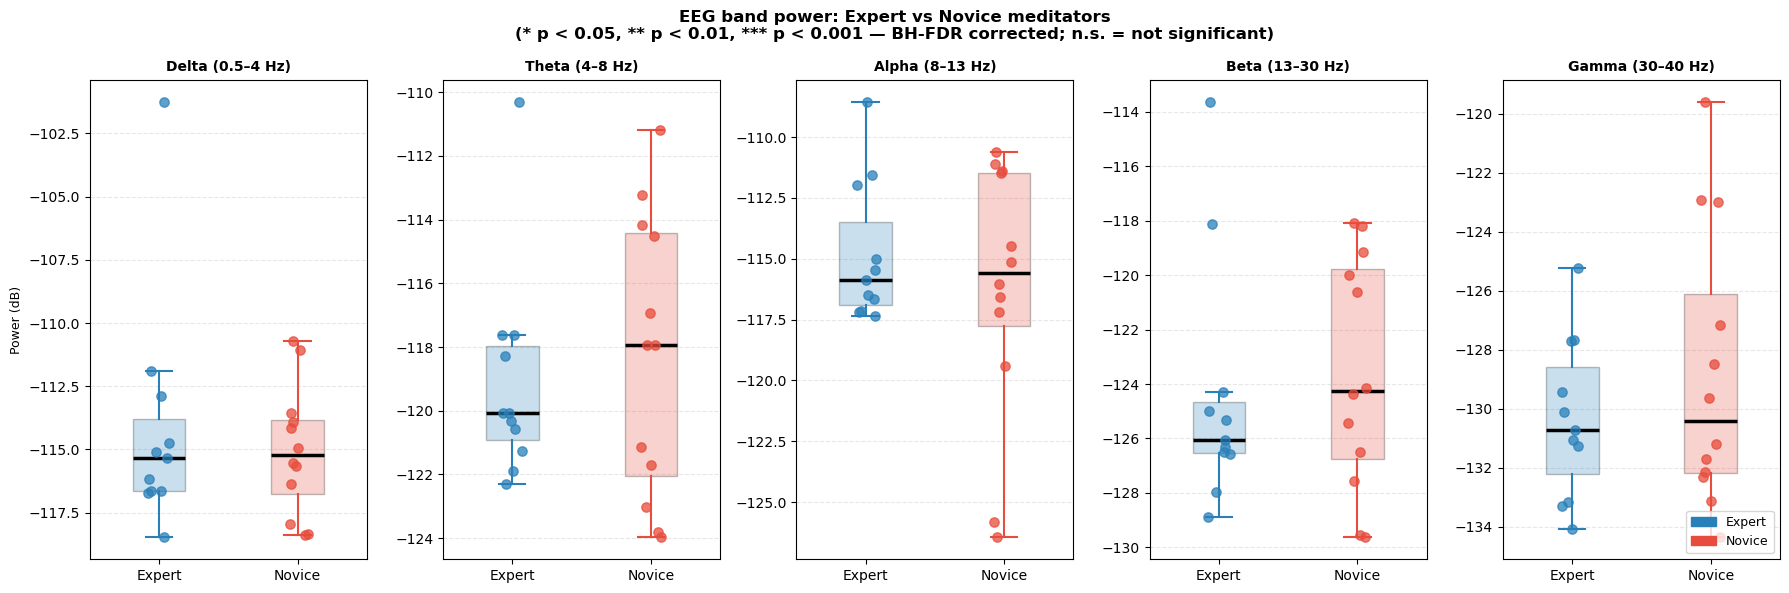

Saved: group_comparison_boxplot.png


In [9]:
np.random.seed(42)   # fix seed for reproducible jitter positions

fig, axes = plt.subplots(1, len(BAND_COLS), figsize=(18, 6), sharey=False)

for ax, col, band_name, row in zip(axes, BAND_COLS, BAND_NAMES, res.itertuples()):

    for pos, (grp_df, color, label) in enumerate(
            [(experts, COLOR_EXP, 'Expert'), (novices, COLOR_NOV, 'Novice')]):

        vals   = grp_df[col].values
        # Horizontal jitter: uniform noise in ±0.08 around the bar x-position.
        # Purely cosmetic — prevents overlapping points from being invisible.
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))

        # Individual data points
        ax.scatter(pos + jitter, vals,
                   color=color, alpha=0.75, s=45, zorder=3)

        # Box plot (patch_artist=True fills the box with colour)
        ax.boxplot(
            vals, positions=[pos], widths=0.38, patch_artist=True,
            boxprops     = dict(facecolor=color, alpha=0.25),
            medianprops  = dict(color='black', lw=2.5),
            whiskerprops = dict(color=color, lw=1.5),
            capprops     = dict(color=color, lw=1.5),
            flierprops   = dict(marker='')   # hide default outlier markers
        )

    # Significance bracket above band if BH-corrected p < 0.05
    if row.significant:
        y_max   = df[col].max()
        y_ann   = y_max + abs(y_max) * 0.02
        ax.annotate('', xy=(1, y_ann), xytext=(0, y_ann),
                    arrowprops=dict(arrowstyle='-', color='black', lw=1.5))
        ax.text(0.5, y_ann, row.sig_label,
                ha='center', va='bottom', fontsize=13)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Expert', 'Novice'], fontsize=10)
    ax.set_title(band_name, fontsize=10, fontweight='bold')
    ax.set_ylabel('Power (dB)' if col == BAND_COLS[0] else '', fontsize=9)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')

exp_patch = mpatches.Patch(color=COLOR_EXP, label='Expert')
nov_patch = mpatches.Patch(color=COLOR_NOV, label='Novice')
axes[-1].legend(handles=[exp_patch, nov_patch], fontsize=9, loc='lower right')

fig.suptitle(
    'EEG band power: Expert vs Novice meditators\n'
    '(* p < 0.05, ** p < 0.01, *** p < 0.001 — BH-FDR corrected; n.s. = not significant)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('group_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: group_comparison_boxplot.png")

### 8b. Scatter plot: theta ~ alpha with regression line

Each point is one subject, coloured by group. The regression line is fitted by ordinary least squares (`numpy.polyfit`). The Pearson correlation and 95% CI computed in Section 7 are annotated in the top-left corner.

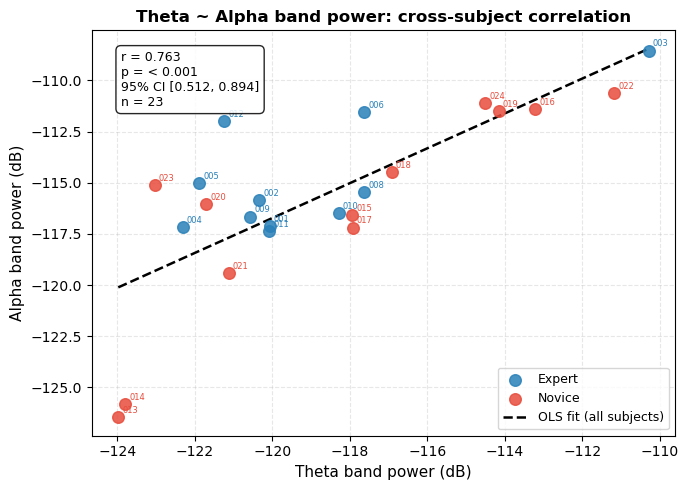

Saved: theta_alpha_correlation.png


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

for grp_df, color, label in [
        (experts, COLOR_EXP, 'Expert'), (novices, COLOR_NOV, 'Novice')]:
    ax.scatter(grp_df['theta_dB'], grp_df['alpha_dB'],
               color=color, s=70, alpha=0.85, label=label, zorder=3)
    # Annotate each point with its subject ID
    for _, row in grp_df.iterrows():
        ax.annotate(row['subject'],
                    (row['theta_dB'], row['alpha_dB']),
                    fontsize=6, color=color,
                    xytext=(3, 3), textcoords='offset points')

# Ordinary least-squares regression line (all subjects)
# np.polyfit(x, y, 1) returns [slope, intercept] of the best-fit line y = ax + b
slope, intercept = np.polyfit(df['theta_dB'], df['alpha_dB'], 1)
x_line = np.linspace(df['theta_dB'].min(), df['theta_dB'].max(), 200)
ax.plot(x_line, slope * x_line + intercept,
        color='black', lw=1.8, linestyle='--', label='OLS fit (all subjects)')

# Correlation annotation box
ax.text(0.05, 0.95,
        f'r = {r_val:.3f}\np = {p_r_str}\n95% CI [{ci_lo:.3f}, {ci_hi:.3f}]\nn = {n}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

ax.set_xlabel('Theta band power (dB)', fontsize=11)
ax.set_ylabel('Alpha band power (dB)', fontsize=11)
ax.set_title('Theta ~ Alpha band power: cross-subject correlation',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('theta_alpha_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: theta_alpha_correlation.png")

### 8c. Cohen's d bar chart

Each bar shows the standardised effect size for one frequency band. Dashed horizontal lines mark Cohen's conventional small, medium, and large thresholds. Blue bars indicate expert > novice; red bars indicate novice > expert.

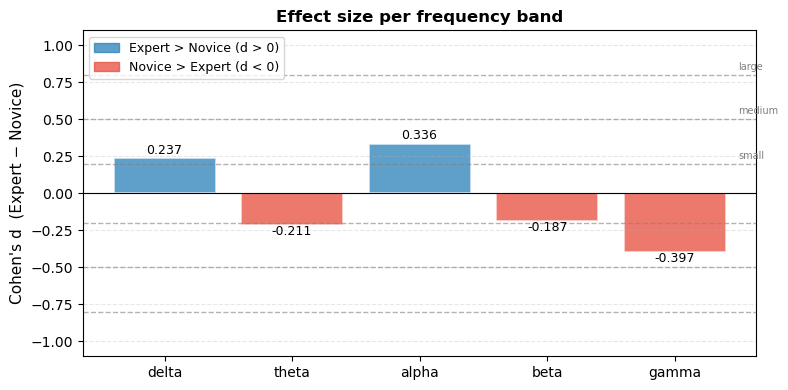

Saved: cohens_d_barplot.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

# Bar colour: blue if experts have more power (d > 0), red if novices do (d < 0)
bar_colors = [COLOR_EXP if d > 0 else COLOR_NOV for d in res['cohen_d']]
bars = ax.bar(BAND_SHORT, res['cohen_d'],
              color=bar_colors, alpha=0.75, edgecolor='white', linewidth=1.2)

# Cohen's convention thresholds (positive and negative sides)
for threshold, label in [(0.2, 'small'), (0.5, 'medium'), (0.8, 'large')]:
    for sign in [1, -1]:
        ax.axhline(sign * threshold, color='grey', lw=1, linestyle='--', alpha=0.6)
for label_txt, y_txt in [('large', 0.82), ('medium', 0.52), ('small', 0.22)]:
    ax.text(len(BAND_SHORT) - 0.5, y_txt, label_txt,
            fontsize=7, color='grey', va='bottom')

# Value labels on each bar
for bar, d_val in zip(bars, res['cohen_d']):
    y_pos = d_val + (0.03 if d_val >= 0 else -0.07)
    ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
            f'{d_val:.3f}', ha='center', fontsize=9)

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel("Cohen's d  (Expert − Novice)", fontsize=11)
ax.set_title("Effect size per frequency band", fontsize=12, fontweight='bold')
ax.set_ylim(min(res['cohen_d'].min() - 0.25, -1.1),
            max(res['cohen_d'].max() + 0.25,  1.1))
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

exp_patch = mpatches.Patch(color=COLOR_EXP, alpha=0.75, label='Expert > Novice (d > 0)')
nov_patch = mpatches.Patch(color=COLOR_NOV, alpha=0.75, label='Novice > Expert (d < 0)')
ax.legend(handles=[exp_patch, nov_patch], fontsize=9)

plt.tight_layout()
plt.savefig('cohens_d_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cohens_d_barplot.png")

---
## 9. Final Summary Table and CSV Export

All results are assembled into a single publication-ready table and exported to `statistical_results.csv` for use in the research paper or downstream analysis.

In [12]:
# ── Publication-ready summary table ──────────────────────────────────────────
summary = res[[
    'band', 'mean_exp', 'std_exp', 'mean_nov', 'std_nov',
    't_stat', 'df_ws', 'p_raw_str', 'p_fdr_str',
    'cohen_d', 'effect_size', 'sig_label'
]].copy()

summary.columns = [
    'Band', 'M Expert (dB)', 'SD Expert', 'M Novice (dB)', 'SD Novice',
    't', 'df (Welch–Satterthwaite)', 'p (raw)', 'p (BH-FDR)',
    "Cohen's d", 'Effect size', 'Sig.'
]

print('=' * 115)
print('  FULL RESULTS — Welch t-test + BH-FDR correction + Cohen\'s d')
print('  Group assignment sourced directly from participants.tsv')
print('=' * 115)
display(summary)

# ── Correlation summary ───────────────────────────────────────────────────────
print()
print(f"Pearson correlation (theta_dB ~ alpha_dB, all subjects, n={n}):")
print(f"  r = {r_val:.3f}  |  p = {p_r_str}  |  95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

# ── Export ────────────────────────────────────────────────────────────────────
summary.to_csv('statistical_results.csv', index=False)
print()
print("Saved: statistical_results.csv")

  FULL RESULTS — Welch t-test + BH-FDR correction + Cohen's d
  Group assignment sourced directly from participants.tsv


,Band,M Expert (dB),SD Expert,M Novice (dB),SD Novice,t,df (Welch–Satterthwaite),p (raw),p (BH-FDR),Cohen's d,Effect size,Sig.
0,delta,-114.170,4.669,-115.050,2.556,0.553,15.2,0.5881,0.6605,0.237,small,n.s.
1,theta,-119.122,3.331,-118.290,4.420,-0.512,20.3,0.6139,0.6605,-0.211,small,n.s.
2,alpha,-114.838,2.884,-116.302,5.354,0.826,17.2,0.4204,0.6605,0.336,small,n.s.
3,beta,-124.425,4.527,-123.604,4.281,-0.446,20.6,0.6605,0.6605,-0.187,small,n.s.
4,gamma,-130.344,2.704,-128.802,4.706,-0.974,17.8,0.3433,0.6605,-0.397,small,n.s.



Pearson correlation (theta_dB ~ alpha_dB, all subjects, n=23):
  r = 0.763  |  p = < 0.001  |  95% CI [0.512, 0.894]

Saved: statistical_results.csv
